# Hướng 2 — ghép GAM với GBM theo quãng đường

> **Mentor:** *"Kiểm tra lại lợi thế của GAM trên nhiều lần chia dữ liệu theo thời gian. Nếu GAM vẫn
> tốt hơn ổn định ở chuyến dài và giá cao, các em có thể thử một cách kết hợp GAM–GBM đơn giản:
> chuyến bình thường ưu tiên GBM, còn chuyến càng dài thì tăng dần ảnh hưởng của GAM. Không cần xây
> thêm kiến trúc phức tạp."*

> **Ràng buộc khi đánh giá:** *"Các em cần giữ nguyên nhóm chuyến giữa các model."* — mọi bảng dưới
> đây chia nhóm theo **giá thật** và **quãng đường**, không model nào tự chia nhóm cho mình.

Notebook này gom kết quả của `02_GAM_ON_DINH` (kiểm định ổn định) và `03_GHEP_GAM_GBM` (dò tham số)
thành **một bảng thống kê ba model** và các hình so sánh trực tiếp. Không train lại gì — đọc dự
đoán đã lưu, nên chạy vài phút.

## Ba model được so

| Model | Là gì | Nguồn |
|---|---|---|
| **GBM** *(mốc)* | Hybrid hai tầng, HistGradientBoosting cho cả hai nhánh | `uq_pred_test.parquet` |
| **GAM** | Cùng kiến trúc hai tầng, thay thuật toán bằng GAM | `pred_gam.parquet` |
| **Ghép GAM–GBM** | Trộn tuyến tính theo quãng đường, đúng mô tả của mentor | tính trong notebook này |

## Cách ghép

$$\hat p = (1 - \alpha(d)) \cdot \hat p_{GBM} + \alpha(d) \cdot \hat p_{GAM}$$

$$\alpha(d) = \alpha_{max} \cdot \text{clip}\!\left(\frac{d - d_0}{d_1 - d_0},\, 0,\, 1\right)$$

Chuyến ngắn dùng nguyên GBM, chuyến càng dài thì GAM càng có tiếng nói, tối đa `α_max`. Hàm liên
tục nên **không có bậc nhảy** — khách đi 13,9 km và 14,1 km không nhận hai mức giá lệch hẳn nhau.

## Kỷ luật đánh giá

Tham số `d₀`, `d₁`, `α_max` được dò trên test tháng **2026-01** ở notebook `03`. Vì vậy con số chính
thức của notebook này báo cáo trên **hai tháng chưa từng đụng tới** (2026-02, 2026-03). Bảng trên
toàn tập vẫn in ra để đối chiếu, nhưng có đánh dấu là **lạc quan** và không dùng làm số nộp.

In [1]:
import warnings, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
KQ   = Path("ket_qua"); KQ.mkdir(exist_ok=True)

MAU_MODEL = {"GBM": BLUE, "GAM": ORANGE, "Ghép": GREEN}

CAT_GIA = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN_GIA = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
CAT_KM  = [0, 2, 5, 8, 12, 15, np.inf]
TEN_KM  = ["<2", "2–5", "5–8", "8–12", "12–15", ">15"]

def mape(p, y):
    p, y = np.asarray(p, float), np.asarray(y, float)
    return float(np.mean(np.abs(p - y) / y))

def boot_hieu(p_moc, p_moi, y, B=2000, seed=7, khoi=250):
    """CI 95% cho (sai số mốc − sai số mới), điểm %. Dương = 'mới' tốt hơn."""
    y = np.asarray(y, float)
    h = np.abs(np.asarray(p_moc, float) - y)/y - np.abs(np.asarray(p_moi, float) - y)/y
    n = len(h)
    if n < 2:
        return float("nan"), float("nan"), float("nan")
    rng, tb = np.random.default_rng(seed), []
    for i in range(0, B, khoi):
        b = min(khoi, B - i)
        tb.append(h[rng.integers(0, n, (b, n))].mean(axis=1))
    tb = np.concatenate(tb)
    return h.mean()*100, float(np.percentile(tb, 2.5))*100, float(np.percentile(tb, 97.5))*100

In [2]:
# ══ Nạp dự đoán đã lưu ═════════════════════════════════════════════════
ut  = pd.read_parquet(EVAL / "uq_pred_test.parquet").reset_index(drop=True)
gam = pd.read_parquet(EVAL / "pred_gam.parquet").reset_index(drop=True)
assert len(ut) == len(gam) and np.allclose(ut.gia_that.values, gam.gia_that.values), \
    "Hai file không cùng thứ tự hàng"

D = pd.DataFrame({
    "thang": ut.evaluation_month.values,
    "lag":   ut.requested_lag_minutes.values,
    "km":    ut.quote_distance.values,
    "y":     ut.gia_that.values,
    "GBM":   ut.hybrid_pred.values,
    "GAM":   gam.hybrid_pred.values,
    "pers":  ut.persistence.values,
})
D = D[D.lag == 5].reset_index(drop=True)
D["band"] = pd.cut(D.y,  CAT_GIA, labels=TEN_GIA)     # nhóm cố định: GIÁ THẬT
D["kmb"]  = pd.cut(D.km, CAT_KM,  labels=TEN_KM)      # nhóm cố định: QUÃNG ĐƯỜNG

# ── tham số ghép: lấy từ 03_GHEP_GAM_GBM ──
cfg = json.load(open(KQ/"B2_cau_hinh.json", encoding="utf-8"))
D0, D1, AMAX, THANG_DO = cfg["d0"], cfg["d1"], cfg["amax"], cfg["thang_do"]

def alpha(d):
    return np.clip((np.asarray(d, float) - D0) / max(D1 - D0, 1e-9), 0, 1) * AMAX

D["Ghép"] = (1 - alpha(D.km)) * D.GBM + alpha(D.km) * D.GAM

SACH = D[D.thang != THANG_DO].reset_index(drop=True)   # 2 tháng chưa đụng tới
MODEL = ["GBM", "GAM", "Ghép"]

print(f"Tham số ghép (dò trên {THANG_DO}): d₀={D0} km · d₁={D1} km · α_max={AMAX}")
print(f"Toàn tập test    : {len(D):,} chuyến ({sorted(D.thang.unique())})")
print(f"Tập đánh giá sạch: {len(SACH):,} chuyến ({sorted(SACH.thang.unique())})")
print(f"\nTỷ lệ chuyến bị ghép tác động: {(alpha(D.km) > 0).mean():.1%} "
      f"· bị ghép ở mức tối đa: {(alpha(D.km) >= AMAX).mean():.2%}")

Tham số ghép (dò trên 2026-01): d₀=6.0 km · d₁=14.0 km · α_max=0.8
Toàn tập test    : 216,090 chuyến (['2026-01', '2026-02', '2026-03'])
Tập đánh giá sạch: 137,250 chuyến (['2026-02', '2026-03'])

Tỷ lệ chuyến bị ghép tác động: 54.1% · bị ghép ở mức tối đa: 0.47%


## 1. Bảng thống kê tổng — ba model cạnh nhau

Sáu chỉ số cho mỗi model. `MdAPE` là trung vị nên không bị đuôi kéo; `% trong ±10%` là ngôn ngữ của
người vận hành; `hơn persistence` cho biết model có thật sự học được gì so với việc lấy thẳng giá
quan sát gần nhất.

In [3]:
def thong_ke(s, cot):
    p, y = s[cot].values, s.y.values
    ae = np.abs(p - y); re = ae / y
    return {"MAPE": re.mean(), "MdAPE": np.median(re), "MAE (đ)": ae.mean(),
            "% trong ±10%": (re <= .10).mean(), "% ngoài ±20%": (re > .20).mean(),
            "Hơn persistence": 1 - ae.mean()/np.abs(s.pers.values - y).mean()}

def bang_tong(s, ten):
    B = pd.DataFrame({m: thong_ke(s, m) for m in MODEL}).T
    B.index.name = ten
    return B

def in_tong(B):
    d = B.copy()
    for c in ["MAPE", "MdAPE", "% trong ±10%", "% ngoài ±20%", "Hơn persistence"]:
        d[c] = (d[c]*100).round(2).astype(str) + "%"
    d["MAE (đ)"] = d["MAE (đ)"].round(0).astype(int).map("{:,}".format)
    print(d.to_string())

TONG_SACH = bang_tong(SACH, "Tập đánh giá sạch (2026-02, 2026-03)")
print("① TẬP ĐÁNH GIÁ SẠCH — hai tháng chưa dùng để dò tham số  ← SỐ CHÍNH THỨC")
in_tong(TONG_SACH)

TONG_FULL = bang_tong(D, "Toàn tập test")
print("\n② TOÀN TẬP TEST — có chứa tháng dò tham số, lạc quan hơn, chỉ để đối chiếu")
in_tong(TONG_FULL)

for ten, s in [("sạch", SACH), ("toàn tập", D)]:
    for m in ["GAM", "Ghép"]:
        d, lo, hi = boot_hieu(s.GBM, s[m], s.y)
        print(f"[{ten:8s}] {m:5s} so với GBM: {d:+.3f} điểm  CI [{lo:+.3f}, {hi:+.3f}]"
              f"  {'✔ khác 0' if (lo > 0 or hi < 0) else '— không phân biệt'}")

① TẬP ĐÁNH GIÁ SẠCH — hai tháng chưa dùng để dò tham số  ← SỐ CHÍNH THỨC
                                        MAPE   MdAPE MAE (đ) % trong ±10% % ngoài ±20% Hơn persistence
Tập đánh giá sạch (2026-02, 2026-03)                                                                  
GBM                                   14.63%  12.15%  18,027       42.29%       26.86%          46.03%
GAM                                   14.86%  12.38%  18,176       41.37%       27.43%          45.58%
Ghép                                  14.62%  12.14%  17,986       42.37%       26.81%          46.15%

② TOÀN TẬP TEST — có chứa tháng dò tham số, lạc quan hơn, chỉ để đối chiếu
                 MAPE   MdAPE MAE (đ) % trong ±10% % ngoài ±20% Hơn persistence
Toàn tập test                                                                  
GBM            14.65%  12.15%  17,926        42.3%       26.89%           46.2%
GAM            14.89%  12.38%  18,082       41.36%       27.49%          45.73%
Ghép           1

[sạch    ] GAM   so với GBM: -0.231 điểm  CI [-0.247, -0.215]  ✔ khác 0


[sạch    ] Ghép  so với GBM: +0.014 điểm  CI [+0.010, +0.018]  ✔ khác 0


[toàn tập] GAM   so với GBM: -0.238 điểm  CI [-0.251, -0.225]  ✔ khác 0


[toàn tập] Ghép  so với GBM: +0.011 điểm  CI [+0.008, +0.014]  ✔ khác 0


## 2. Bảng chi tiết theo nhóm cố định

Hai bảng: theo quãng đường và theo giá thật. Mỗi nhóm có MAPE của ba model, cộng chênh lệch so với
GBM kèm khoảng tin cậy bootstrap.

In [4]:
def bang_theo_nhom(s, cot_nhom, ten_nhom_list, nhan):
    hang = []
    for g in ten_nhom_list:
        sub = s[s[cot_nhom].astype(str) == g]
        if len(sub) < 30:
            continue
        r = {nhan: g, "n": len(sub)}
        for m in MODEL:
            r[m] = mape(sub[m], sub.y)
        for m in ["GAM", "Ghép"]:
            d, lo, hi = boot_hieu(sub.GBM, sub[m], sub.y)
            r[f"Δ {m}"] = d
            r[f"lo {m}"], r[f"hi {m}"] = lo, hi
            r[f"CI {m}"] = f"[{lo:+.2f}, {hi:+.2f}]"
            r[f"thật {m}"] = "✔" if lo > 0 else ("✘" if hi < 0 else "—")
        hang.append(r)
    sub = s
    r = {nhan: "TOÀN BỘ", "n": len(sub)}
    for m in MODEL:
        r[m] = mape(sub[m], sub.y)
    for m in ["GAM", "Ghép"]:
        d, lo, hi = boot_hieu(sub.GBM, sub[m], sub.y)
        r[f"Δ {m}"], r[f"CI {m}"] = d, f"[{lo:+.2f}, {hi:+.2f}]"
        r[f"lo {m}"], r[f"hi {m}"] = lo, hi
        r[f"thật {m}"] = "✔" if lo > 0 else ("✘" if hi < 0 else "—")
    hang.append(r)
    return pd.DataFrame(hang)

fmt = {**{m: "{:.2%}".format for m in MODEL},
       "Δ GAM": "{:+.2f}".format, "Δ Ghép": "{:+.2f}".format, "n": "{:,}".format}

B_KM  = bang_theo_nhom(SACH, "kmb",  TEN_KM,  "Nhóm km")
B_GIA = bang_theo_nhom(SACH, "band", TEN_GIA, "Nhóm giá thật")

COT_AN = [c for c in B_KM.columns if c.startswith(("lo ", "hi "))]
print("THEO QUÃNG ĐƯỜNG — tập đánh giá sạch · Δ dương = tốt hơn GBM (điểm %)")
print(B_KM.drop(columns=COT_AN).to_string(index=False, formatters=fmt))
print("\n✔ = khoảng tin cậy loại trừ 0 (tốt hơn thật) · ✘ = xấu đi thật · — = không phân biệt")

THEO QUÃNG ĐƯỜNG — tập đánh giá sạch · Δ dương = tốt hơn GBM (điểm %)
Nhóm km       n    GBM    GAM   Ghép Δ GAM         CI GAM thật GAM Δ Ghép        CI Ghép thật Ghép
     <2   5,288  9.25% 13.47%  9.25% -4.23 [-4.44, -4.01]        ✘  +0.00 [+0.00, +0.00]         —
    2–5  17,055 14.19% 14.46% 14.19% -0.27 [-0.32, -0.22]        ✘  +0.00 [+0.00, +0.00]         —
    5–8  79,498 14.97% 15.02% 14.96% -0.06 [-0.07, -0.04]        ✘  +0.00 [+0.00, +0.00]         ✔
   8–12  33,712 14.84% 14.90% 14.83% -0.06 [-0.09, -0.03]        ✘  +0.01 [-0.00, +0.02]         —
  12–15   1,269 15.18% 14.79% 14.80% +0.39 [+0.11, +0.66]        ✔  +0.38 [+0.17, +0.59]         ✔
    >15     428 18.12% 15.47% 15.61% +2.65 [+1.70, +3.67]        ✔  +2.50 [+1.73, +3.36]         ✔
TOÀN BỘ 137,250 14.63% 14.86% 14.62% -0.23 [-0.25, -0.22]        ✘  +0.01 [+0.01, +0.02]         ✔

✔ = khoảng tin cậy loại trừ 0 (tốt hơn thật) · ✘ = xấu đi thật · — = không phân biệt


In [5]:
print("THEO GIÁ THẬT — tập đánh giá sạch · Δ dương = tốt hơn GBM (điểm %)")
print(B_GIA.drop(columns=COT_AN).to_string(index=False, formatters=fmt))

THEO GIÁ THẬT — tập đánh giá sạch · Δ dương = tốt hơn GBM (điểm %)
Nhóm giá thật       n    GBM    GAM   Ghép Δ GAM         CI GAM thật GAM Δ Ghép        CI Ghép thật Ghép
         <50k   2,109 20.16% 25.77% 20.15% -5.61 [-5.93, -5.26]        ✘  +0.00 [-0.00, +0.00]         —
      50–100k  44,942 16.34% 16.65% 16.33% -0.31 [-0.34, -0.28]        ✘  +0.01 [+0.01, +0.01]         ✔
     100–150k  56,935 12.85% 12.84% 12.84% +0.00 [-0.01, +0.02]        —  +0.01 [+0.01, +0.01]         ✔
     150–200k  24,267 13.75% 14.03% 13.75% -0.28 [-0.31, -0.25]        ✘  -0.01 [-0.02, +0.00]         —
     200–300k   8,449 18.09% 18.12% 18.05% -0.03 [-0.09, +0.03]        —  +0.04 [+0.01, +0.08]         ✔
        >300k     548 24.04% 22.22% 22.49% +1.82 [+1.20, +2.46]        ✔  +1.55 [+1.04, +2.09]         ✔
      TOÀN BỘ 137,250 14.63% 14.86% 14.62% -0.23 [-0.25, -0.22]        ✘  +0.01 [+0.01, +0.02]         ✔


## 3. So sánh trực tiếp theo quãng đường

Đây là hình trung tâm: ba model trên cùng một trục, kèm đường trọng số `α(d)` để thấy chỗ nào GAM
được cho tiếng nói và chỗ nào không.

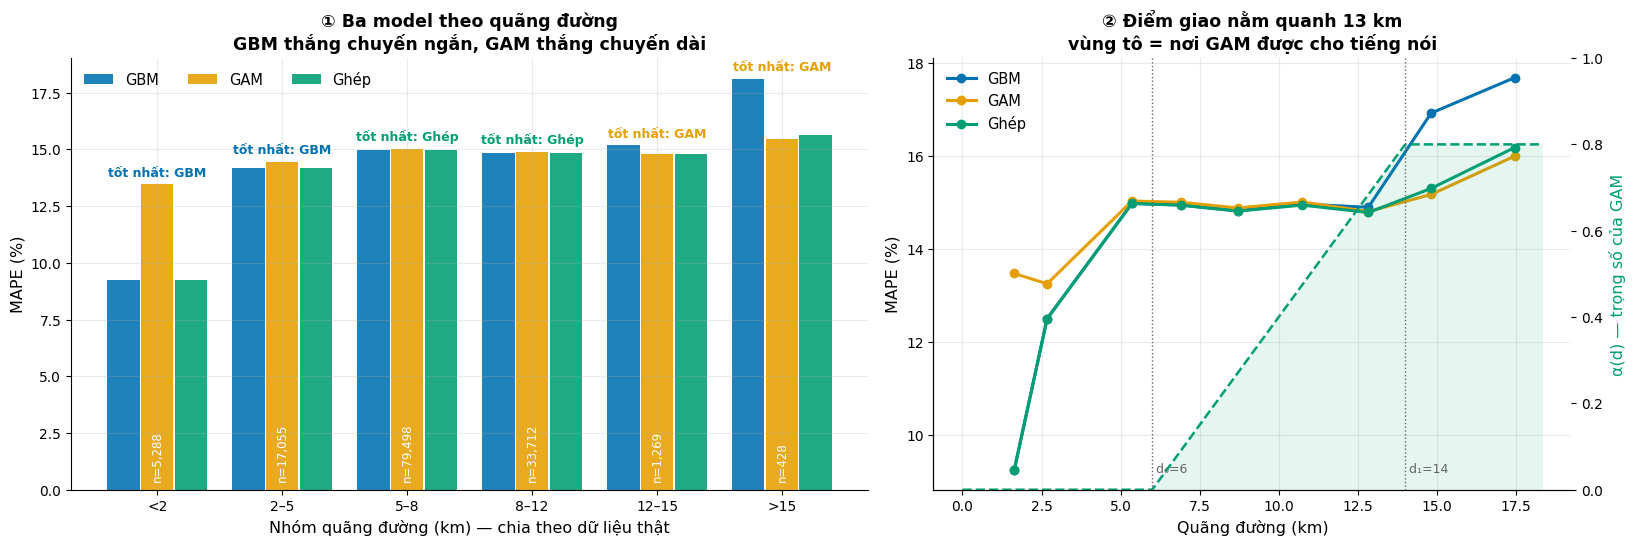

In [6]:
# ═════════ HINH H2_1 — ba model theo quang duong ═════════
fig, ax = plt.subplots(1, 2, figsize=(16.5, 5.6),
                       gridspec_kw={"width_ratios": [1.25, 1]})

g = B_KM[B_KM["Nhóm km"] != "TOÀN BỘ"]
x = np.arange(len(g))
for i, m in enumerate(MODEL):
    ax[0].bar(x + (i-1)*.27, g[m]*100, .26, color=MAU_MODEL[m], alpha=.88, label=m)
for i in x:
    tot = min(MODEL, key=lambda m: g[m].iloc[i])
    ax[0].text(i, g[MODEL].iloc[i].max()*100 + .35, f"tốt nhất: {tot}",
               ha="center", fontsize=9, color=MAU_MODEL[tot], fontweight="bold")
for i in x:
    ax[0].text(i, .5, f"n={g.n.iloc[i]:,}", ha="center", fontsize=8.5, color="white",
               rotation=90)
ax[0].set_xticks(x); ax[0].set_xticklabels(g["Nhóm km"])
ax[0].set_xlabel("Nhóm quãng đường (km) — chia theo dữ liệu thật")
ax[0].set_ylabel("MAPE (%)"); ax[0].legend(frameon=False, ncol=3)
ax[0].set_title("① Ba model theo quãng đường\nGBM thắng chuyến ngắn, GAM thắng chuyến dài",
                fontweight="bold")

# ② đường cong theo km liên tục + alpha
b = SACH.copy()
b["bin"] = pd.cut(b.km, [0, 2, 4, 6, 8, 10, 12, 14, 16, 20, 50])
gg = b.groupby("bin", observed=True).apply(
    lambda s: pd.Series({m: mape(s[m], s.y)*100 for m in MODEL} | {"n": len(s),
                        "km": s.km.mean()}))
gg = gg[gg.n >= 100]
for m in MODEL:
    ax[1].plot(gg.km, gg[m], "o-", color=MAU_MODEL[m], lw=2.2, ms=6, label=m)
ax[1].set_xlabel("Quãng đường (km)"); ax[1].set_ylabel("MAPE (%)")
ax[1].legend(frameon=False, loc="upper left")
a2 = ax[1].twinx()
xx = np.linspace(0, gg.km.max()*1.05, 300)
a2.fill_between(xx, 0, alpha(xx), color=GREEN, alpha=.10, lw=0)
a2.plot(xx, alpha(xx), color=GREEN, lw=1.8, ls="--")
a2.set_ylabel("α(d) — trọng số của GAM", color=GREEN)
a2.set_ylim(0, 1); a2.grid(False)
a2.axvline(D0, color=MUT, lw=1, ls=":"); a2.axvline(D1, color=MUT, lw=1, ls=":")
a2.text(D0, .04, f" d₀={D0:.0f}", ha="left", fontsize=9, color=MUT)
a2.text(D1, .04, f" d₁={D1:.0f}", ha="left", fontsize=9, color=MUT)
ax[1].set_title("② Điểm giao nằm quanh 13 km\nvùng tô = nơi GAM được cho tiếng nói",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"H2_1_ba_model_theo_km.png"); plt.show()

## 4. So sánh trực tiếp theo mức giá

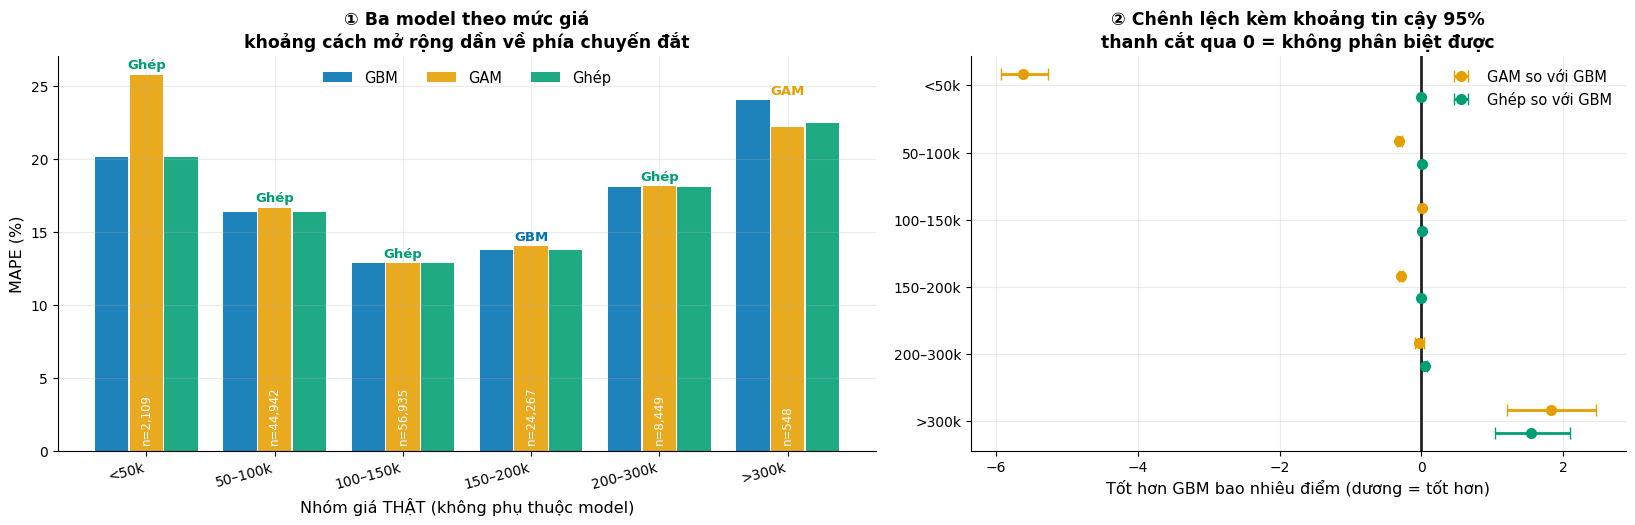

In [7]:
# ═════════ HINH H2_2 — ba model theo band gia that ═════════
fig, ax = plt.subplots(1, 2, figsize=(16.5, 5.4),
                       gridspec_kw={"width_ratios": [1.25, 1]})

g = B_GIA[B_GIA["Nhóm giá thật"] != "TOÀN BỘ"]
x = np.arange(len(g))
for i, m in enumerate(MODEL):
    ax[0].bar(x + (i-1)*.27, g[m]*100, .26, color=MAU_MODEL[m], alpha=.88, label=m)
for i in x:
    tot = min(MODEL, key=lambda m: g[m].iloc[i])
    ax[0].text(i, g[MODEL].iloc[i].max()*100 + .4, f"{tot}", ha="center",
               fontsize=9.5, color=MAU_MODEL[tot], fontweight="bold")
    ax[0].text(i, .6, f"n={g.n.iloc[i]:,}", ha="center", fontsize=8.5, color="white",
               rotation=90)
ax[0].set_xticks(x); ax[0].set_xticklabels(g["Nhóm giá thật"], rotation=15, ha="right")
ax[0].set_xlabel("Nhóm giá THẬT (không phụ thuộc model)")
ax[0].set_ylabel("MAPE (%)"); ax[0].legend(frameon=False, ncol=3)
ax[0].set_title("① Ba model theo mức giá\nkhoảng cách mở rộng dần về phía chuyến đắt",
                fontweight="bold")

# ② chênh lệch so với GBM, kèm CI
y_ = np.arange(len(g))[::-1]
for m, off in [("GAM", .17), ("Ghép", -.17)]:
    lo, hi = g[f"lo {m}"].values, g[f"hi {m}"].values
    dd = g[f"Δ {m}"].values
    ax[1].errorbar(dd, y_ + off,
                   xerr=[np.clip(dd-lo, 0, None), np.clip(hi-dd, 0, None)],
                   fmt="o", color=MAU_MODEL[m], ecolor=MAU_MODEL[m], ms=7,
                   elinewidth=2, capsize=4, label=f"{m} so với GBM")
ax[1].axvline(0, color=INK, lw=2)
ax[1].set_yticks(y_); ax[1].set_yticklabels(g["Nhóm giá thật"])
ax[1].set_xlabel("Tốt hơn GBM bao nhiêu điểm (dương = tốt hơn)")
ax[1].legend(frameon=False)
ax[1].set_title("② Chênh lệch kèm khoảng tin cậy 95%\nthanh cắt qua 0 = không phân biệt được",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"H2_2_ba_model_theo_gia.png"); plt.show()

## 5. Lợi thế của GAM có ổn định qua các lần chia thời gian không

Đây là điều kiện mentor đặt ra **trước** khi cho phép ghép. Dữ liệu lấy từ `02_GAM_ON_DINH`: ba
tháng, mỗi tháng thêm hai nửa, tổng cộng 9 lát thời gian.

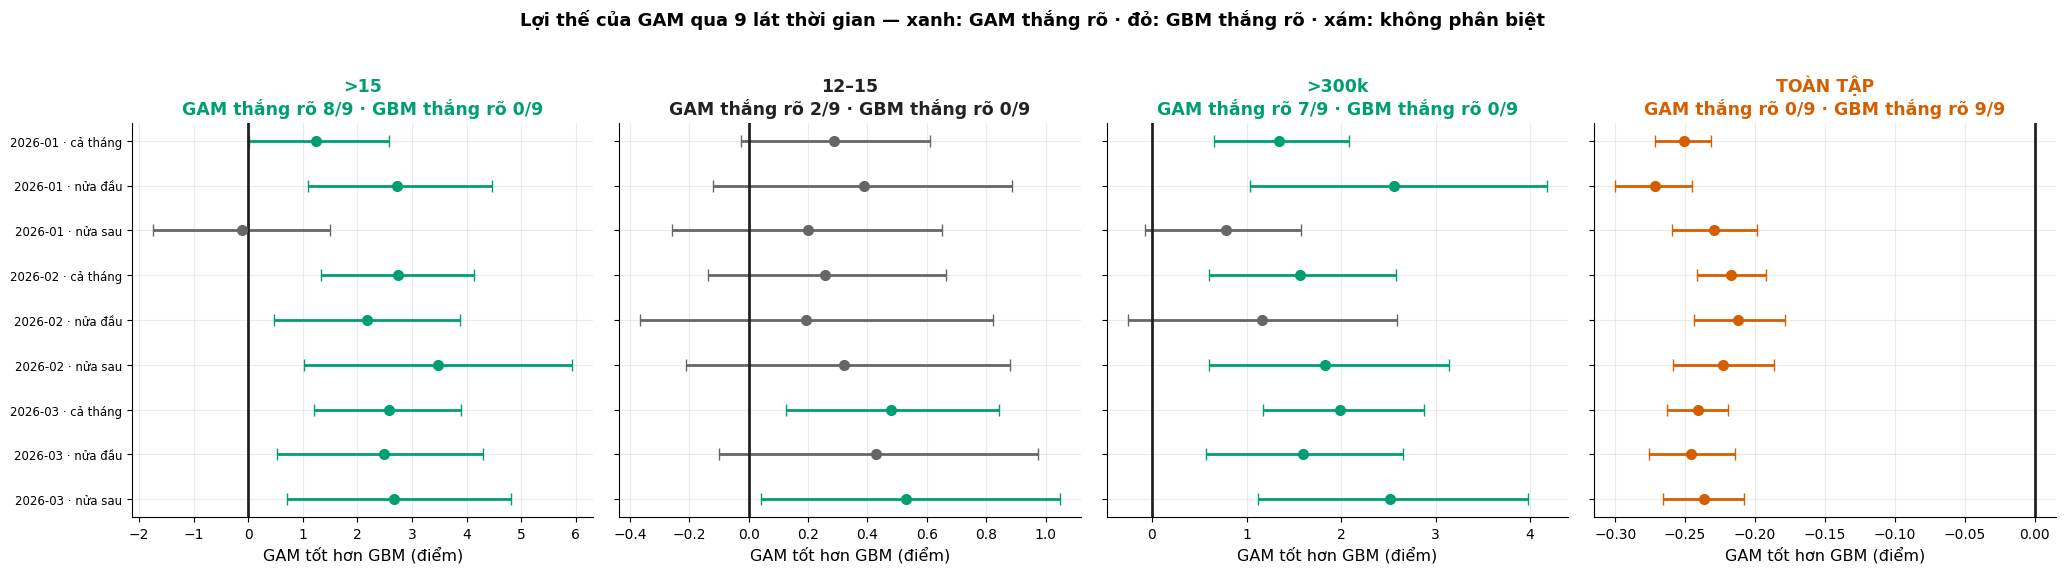

    Nhóm  Số lát  Lát GAM thắng rõ  Lát Hybrid thắng rõ  Lát không phân biệt  Chênh nhỏ nhất  Chênh lớn nhất                 Kết luận
     >15       9                 8                    0                    1       -0.116881        3.467758    ✔ ổn định · GAM thắng
   12–15       9                 2                    0                    7        0.194423        0.529532    ✔ ổn định · GAM thắng
    8–12       9                 0                    6                    3       -0.112728       -0.019757 ✔ ổn định · Hybrid thắng
   >300k       9                 7                    0                    2        0.781757        2.556929    ✔ ổn định · GAM thắng
200–300k       9                 1                    2                    6       -0.202225        0.197403              ✘ mâu thuẫn
TOÀN TẬP       9                 0                    9                    0       -0.271728       -0.211836 ✔ ổn định · Hybrid thắng


In [8]:
# ═════════ HINH H2_3 — on dinh qua 9 lat ═════════
OD = pd.read_csv(KQ/"B1_on_dinh_theo_lat.csv")
NHOM_VE = [">15", "12–15", ">300k", "TOÀN TẬP"]
fig, ax = plt.subplots(1, len(NHOM_VE), figsize=(5.2*len(NHOM_VE), 5.6), sharey=True)

for k, nh in enumerate(NHOM_VE):
    s = OD[OD.Nhóm == nh].reset_index(drop=True)
    a = ax[k]
    yy = np.arange(len(s))[::-1]
    for i in range(len(s)):
        lo, hi, ch = s["CI thấp"][i], s["CI cao"][i], s["Chênh"][i]
        mau = GREEN if lo > 0 else (RED if hi < 0 else MUT)
        a.errorbar(ch, yy[i], xerr=[[ch-lo], [hi-ch]], fmt="o", color=mau,
                   ecolor=mau, ms=7, elinewidth=2, capsize=4)
    a.axvline(0, color=INK, lw=2)
    a.set_yticks(yy); a.set_yticklabels(s["Lát"], fontsize=8.5)
    a.set_xlabel("GAM tốt hơn GBM (điểm)")
    thang = (s["CI thấp"] > 0).sum(); thua = (s["CI cao"] < 0).sum()
    a.set_title(f"{nh}\nGAM thắng rõ {thang}/9 · GBM thắng rõ {thua}/9",
                fontweight="bold",
                color=GREEN if thang >= 6 else (RED if thua >= 6 else INK))

fig.suptitle("Lợi thế của GAM qua 9 lát thời gian — xanh: GAM thắng rõ · đỏ: GBM thắng rõ · "
             "xám: không phân biệt", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig(HINH/"H2_3_on_dinh_theo_lat.png", bbox_inches="tight"); plt.show()

TK = pd.read_csv(KQ/"B1_tong_ket_on_dinh.csv")
print(TK.to_string(index=False))

## 6. Ghép có làm giá nhảy bậc không

Mentor yêu cầu *"không cần xây thêm kiến trúc phức tạp"*, nhưng một cách ghép đơn giản vẫn có thể
hỏng nếu giá nhảy bậc tại ngưỡng: hai chuyến 13,9 km và 14,1 km mà nhận giá lệch hẳn nhau thì không
đưa vào vận hành được.

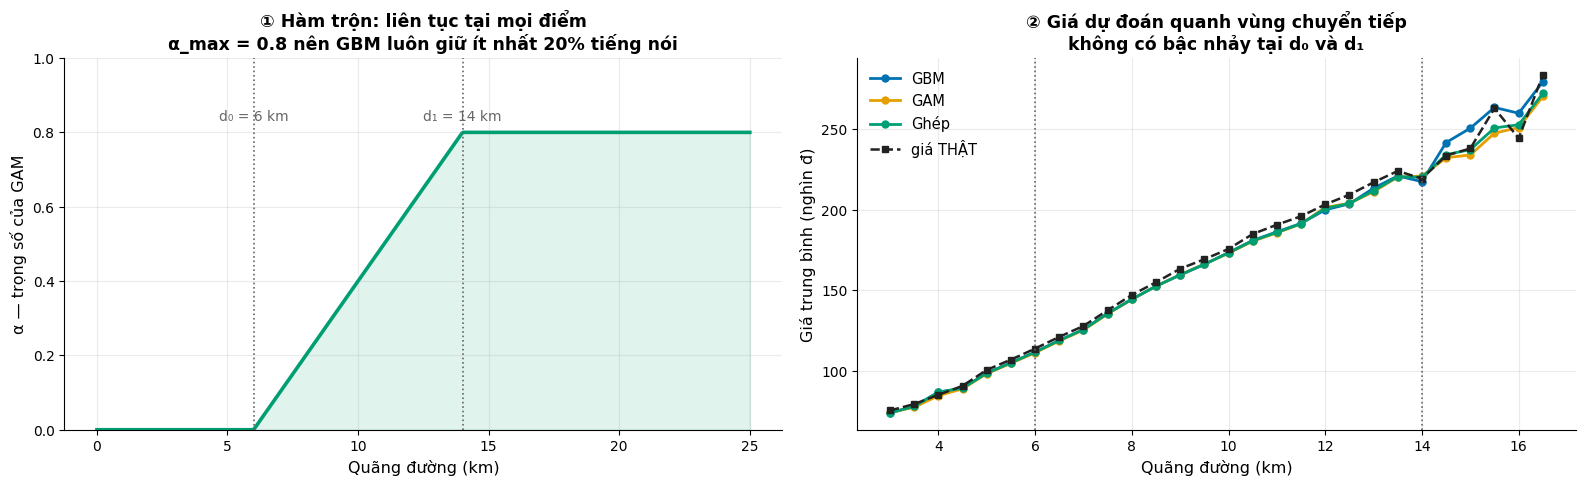

Bước nhảy tương đối lớn nhất giữa hai mốc 0,5 km liên tiếp:
  GBM   11.51%  (trung vị 4.77%)
  GAM   10.60%  (trung vị 5.14%)
  Ghép  11.51%  (trung vị 4.97%)

⇒ Ghép KHÔNG tạo thêm bậc nhảy: chênh lệch bước nhảy lớn nhất so với GBM chỉ +0.00 điểm.
   Bậc nhảy còn lại là do giá vốn tăng theo quãng đường, không phải do hàm trộn.


In [9]:
# ═════════ HINH H2_4 — chuyen tiep muot ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

xx = np.linspace(0, 25, 500)
ax[0].plot(xx, alpha(xx), color=GREEN, lw=2.6)
ax[0].fill_between(xx, 0, alpha(xx), color=GREEN, alpha=.12)
for v, ten in [(D0, "d₀"), (D1, "d₁")]:
    ax[0].axvline(v, color=MUT, lw=1.2, ls=":")
    ax[0].text(v, AMAX*1.04, f"{ten} = {v:.0f} km", ha="center", fontsize=10, color=MUT)
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("α — trọng số của GAM")
ax[0].set_ylim(0, 1)
ax[0].set_title(f"① Hàm trộn: liên tục tại mọi điểm\nα_max = {AMAX} nên GBM luôn giữ ít nhất "
                f"{1-AMAX:.0%} tiếng nói", fontweight="bold")

# ② giá dự đoán trung bình quanh vùng chuyển tiếp
b = SACH[(SACH.km >= D0-3) & (SACH.km <= D1+4)].copy()
b["bin"] = (b.km*2).round()/2
gg = b.groupby("bin").apply(lambda s: pd.Series(
    {m: s[m].mean()/1000 for m in MODEL} | {"y": s.y.mean()/1000, "n": len(s)}))
gg = gg[gg.n >= 40]
for m in MODEL:
    ax[1].plot(gg.index, gg[m], "o-", color=MAU_MODEL[m], lw=2, ms=5, label=m)
ax[1].plot(gg.index, gg.y, "s--", color=INK, lw=1.8, ms=4, label="giá THẬT")
for v in [D0, D1]:
    ax[1].axvline(v, color=MUT, lw=1.2, ls=":")
ax[1].set_xlabel("Quãng đường (km)"); ax[1].set_ylabel("Giá trung bình (nghìn đ)")
ax[1].legend(frameon=False)
ax[1].set_title("② Giá dự đoán quanh vùng chuyển tiếp\nkhông có bậc nhảy tại d₀ và d₁",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"H2_4_chuyen_tiep.png"); plt.show()

# do buoc nhay lon nhat giua hai bin lien tiep
# So bước nhảy giữa hai mốc 0,5 km liên tiếp — tính GIỐNG NHAU cho cả ba đường
# để so được. Giá vốn tăng theo quãng đường nên bước nhảy khác 0 là bình thường;
# điều cần kiểm là ghép có tạo thêm bậc nhảy so với chính GBM hay không.
print("Bước nhảy tương đối lớn nhất giữa hai mốc 0,5 km liên tiếp:")
for m in MODEL:
    b = np.abs(np.diff(gg[m].values)) / gg[m].values[:-1]
    print(f"  {m:5s} {b.max():.2%}  (trung vị {np.median(b):.2%})")
b_ghep = np.abs(np.diff(gg["Ghép"].values)) / gg["Ghép"].values[:-1]
b_gbm  = np.abs(np.diff(gg.GBM.values)) / gg.GBM.values[:-1]
print(f"\n⇒ Ghép KHÔNG tạo thêm bậc nhảy: chênh lệch bước nhảy lớn nhất so với GBM chỉ "
      f"{(b_ghep.max()-b_gbm.max())*100:+.2f} điểm.")
print("   Bậc nhảy còn lại là do giá vốn tăng theo quãng đường, không phải do hàm trộn.")

## 7. Ghép thắng ở đâu, thua ở đâu

Trung bình nhóm có thể che mất chuyện "thắng nhiều ca nhỏ, thua vài ca lớn". Phần này đếm **theo
từng chuyến**: bao nhiêu phần trăm chuyến được ghép cải thiện, và phần cải thiện đó dồn ở đâu.

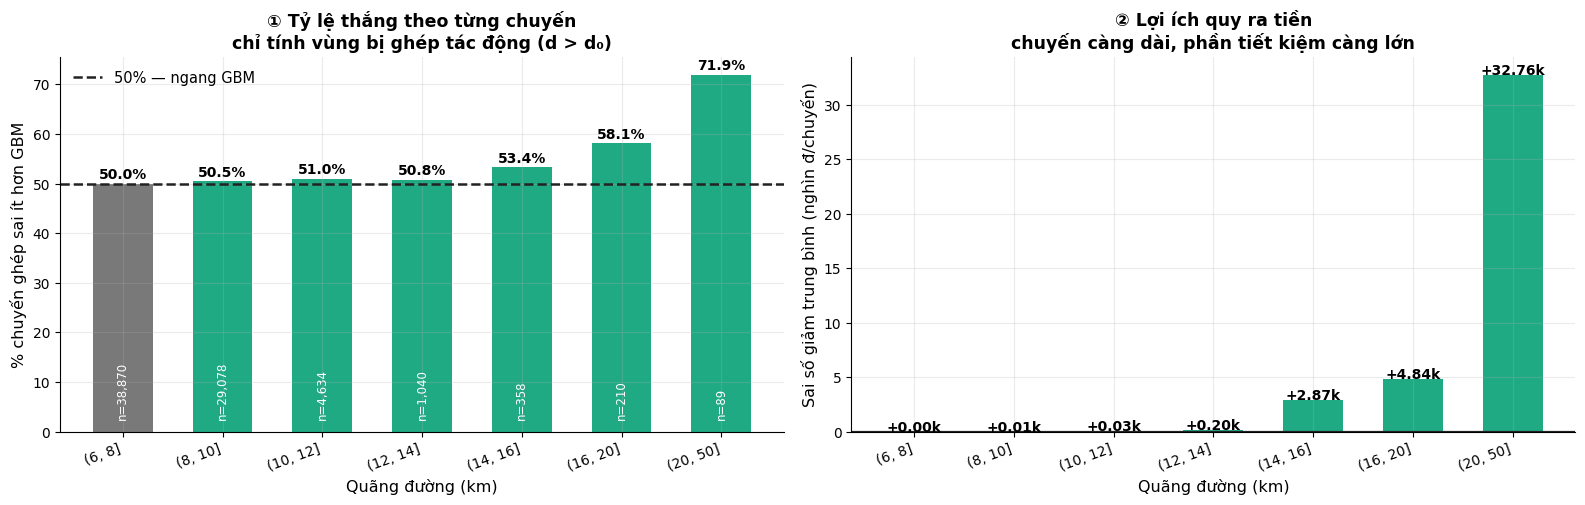

So từng chuyến, ghép so với GBM:
toàn bộ tập đánh giá sạch    n=137,250  tốt hơn  27.2% · kém hơn  26.9% · y hệt  45.9%
chuyến ≤ 6 km (không trộn)   n= 62,971  tốt hơn   0.0% · kém hơn   0.0% · y hệt 100.0%
chuyến > 6 km (có trộn)      n= 74,279  tốt hơn  50.3% · kém hơn  49.7% · y hệt   0.0%
chuyến > 15 km               n=    428  tốt hơn  60.3% · kém hơn  39.7% · y hệt   0.0%

'y hệt' là những chuyến có α(d) = 0 — ghép để nguyên dự đoán của GBM, không phải hoà.


In [10]:
# ═════════ HINH H2_5 — thang thua theo tung chuyen ═════════
S = SACH.copy()
S["ae_gbm"]  = np.abs(S.GBM - S.y)
S["ae_ghep"] = np.abs(S["Ghép"] - S.y)
S["tot_hon"] = S.ae_ghep < S.ae_gbm
S["giam"]    = S.ae_gbm - S.ae_ghep          # dương = ghép sai ít hơn

fig, ax = plt.subplots(1, 2, figsize=(16, 5.2))

g = S[S.km > D0].groupby(pd.cut(S[S.km > D0].km, [6, 8, 10, 12, 14, 16, 20, 50]),
                         observed=True).apply(
    lambda s: pd.Series({"ty_le": s.tot_hon.mean()*100, "n": len(s),
                         "giam_tb": s.giam.mean()}))
x = np.arange(len(g))
mau = [GREEN if v > 50 else MUT for v in g.ty_le]
ax[0].bar(x, g.ty_le, .6, color=mau, alpha=.88)
ax[0].axhline(50, color=INK, lw=1.8, ls="--", label="50% — ngang GBM")
for i in x:
    ax[0].text(i, g.ty_le.iloc[i]+1, f"{g.ty_le.iloc[i]:.1f}%", ha="center",
               fontsize=10, fontweight="bold")
    ax[0].text(i, 3, f"n={int(g.n.iloc[i]):,}", ha="center", fontsize=8.5, color="white",
               rotation=90)
ax[0].set_xticks(x); ax[0].set_xticklabels([str(i) for i in g.index], rotation=20, ha="right")
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("% chuyến ghép sai ít hơn GBM")
ax[0].legend(frameon=False)
ax[0].set_title("① Tỷ lệ thắng theo từng chuyến\nchỉ tính vùng bị ghép tác động (d > d₀)",
                fontweight="bold")

ax[1].bar(x, g.giam_tb/1000, .6, color=[GREEN if v > 0 else RED for v in g.giam_tb], alpha=.88)
ax[1].axhline(0, color=INK, lw=1.6)
for i in x:
    ax[1].text(i, g.giam_tb.iloc[i]/1000 + (.05 if g.giam_tb.iloc[i] > 0 else -.12),
               f"{g.giam_tb.iloc[i]/1000:+.2f}k", ha="center", fontsize=10, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels([str(i) for i in g.index], rotation=20, ha="right")
ax[1].set_xlabel("Quãng đường (km)")
ax[1].set_ylabel("Sai số giảm trung bình (nghìn đ/chuyến)")
ax[1].set_title("② Lợi ích quy ra tiền\nchuyến càng dài, phần tiết kiệm càng lớn",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"H2_5_thang_thua_tung_chuyen.png"); plt.show()

# Ghi rõ ba trạng thái: tốt hơn / kém hơn / y hệt (alpha = 0 nên không đụng tới)
def ba_trang_thai(s, ten):
    yhet = (s.ae_ghep == s.ae_gbm).mean()
    tot  = (s.ae_ghep < s.ae_gbm).mean()
    kem  = (s.ae_ghep > s.ae_gbm).mean()
    print(f"{ten:28s} n={len(s):>7,}  tốt hơn {tot:>6.1%} · kém hơn {kem:>6.1%} "
          f"· y hệt {yhet:>6.1%}")

print("So từng chuyến, ghép so với GBM:")
ba_trang_thai(S, "toàn bộ tập đánh giá sạch")
ba_trang_thai(S[S.km <= D0], f"chuyến ≤ {D0:.0f} km (không trộn)")
ba_trang_thai(S[S.km > D0], f"chuyến > {D0:.0f} km (có trộn)")
ba_trang_thai(S[S.km > 15], "chuyến > 15 km")
print("\n'y hệt' là những chuyến có α(d) = 0 — ghép để nguyên dự đoán của GBM, "
      "không phải hoà.")

## 8. Tổng kết một hình — nhận được gì, trả bao nhiêu

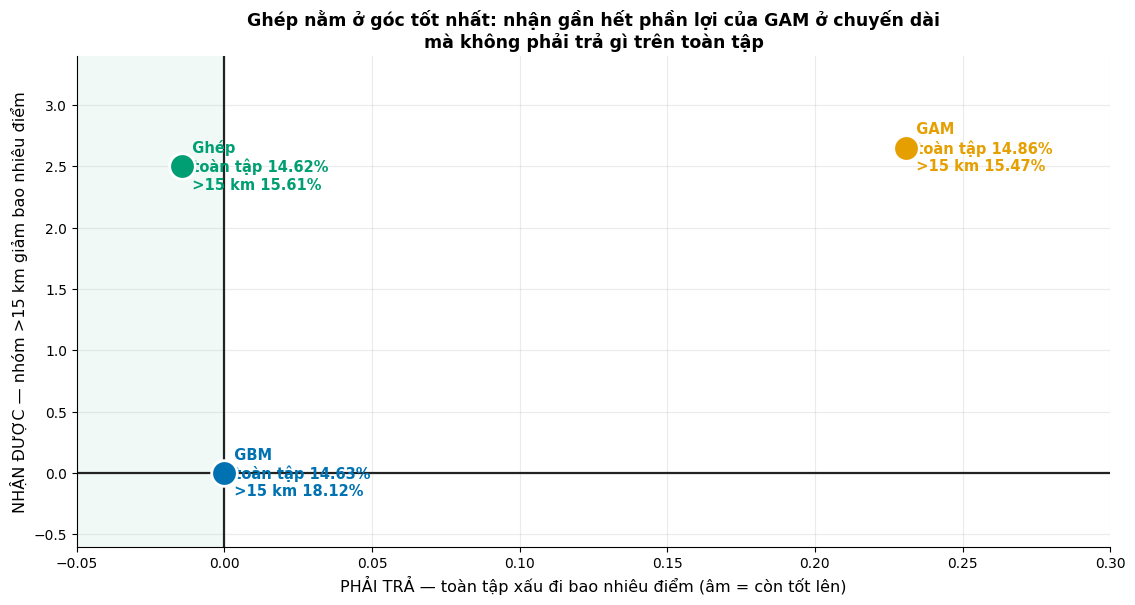

In [11]:
# ═════════ HINH H2_6 — tong ket danh doi ═════════
fig, ax = plt.subplots(figsize=(11.5, 6.2))
s_dai = SACH[SACH.km > 15]
for m in MODEL:
    x = (mape(SACH[m], SACH.y) - mape(SACH.GBM, SACH.y)) * 100      # phải trả
    y = (mape(s_dai.GBM, s_dai.y) - mape(s_dai[m], s_dai.y)) * 100  # nhận được
    ax.scatter(x, y, s=340, color=MAU_MODEL[m], zorder=5, edgecolor="white", lw=2)
    ax.annotate(f"  {m}\n  toàn tập {mape(SACH[m], SACH.y):.2%}\n"
                f"  >15 km {mape(s_dai[m], s_dai.y):.2%}",
                (x, y), fontsize=10.5, va="center", color=MAU_MODEL[m], fontweight="bold")
ax.axhline(0, color=INK, lw=1.6); ax.axvline(0, color=INK, lw=1.6)
ax.axvspan(-1, 0, color=GREEN, alpha=.06, lw=0)
ax.set_xlim(-.05, .30); ax.set_ylim(-.6, 3.4)
ax.set_xlabel("PHẢI TRẢ — toàn tập xấu đi bao nhiêu điểm (âm = còn tốt lên)")
ax.set_ylabel("NHẬN ĐƯỢC — nhóm >15 km giảm bao nhiêu điểm")
ax.set_title("Ghép nằm ở góc tốt nhất: nhận gần hết phần lợi của GAM ở chuyến dài\n"
             "mà không phải trả gì trên toàn tập", fontweight="bold")
plt.tight_layout(); plt.savefig(HINH/"H2_6_tong_ket.png"); plt.show()

In [12]:
# ══ Lưu kết quả ════════════════════════════════════════════════════════
TONG_SACH.to_csv(KQ/"H2_tong_ket_3_model.csv")
TONG_FULL.to_csv(KQ/"H2_tong_ket_3_model_toan_tap.csv")
B_KM.to_csv(KQ/"H2_theo_km.csv", index=False)
B_GIA.to_csv(KQ/"H2_theo_gia.csv", index=False)
d_g, lo_g, hi_g = boot_hieu(SACH.GBM, SACH["Ghép"], SACH.y)
s_dai = SACH[SACH.km > 15]
d_d, lo_d, hi_d = boot_hieu(s_dai.GBM, s_dai["Ghép"], s_dai.y)
json.dump({"d0": D0, "d1": D1, "amax": AMAX, "thang_do": THANG_DO,
           "n_sach": int(len(SACH)),
           "mape": {m: mape(SACH[m], SACH.y) for m in MODEL},
           "ghep_vs_gbm_toan_tap": {"delta": d_g, "ci": [lo_g, hi_g]},
           "ghep_vs_gbm_15km": {"delta": d_d, "ci": [lo_d, hi_d], "n": int(len(s_dai))}},
          open(KQ/"H2_cau_hinh.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1)
print("Đã lưu:", *[p.name for p in sorted(KQ.glob("H2_*"))], sep="\n  ")

Đã lưu:
  H2_cau_hinh.json
  H2_theo_gia.csv
  H2_theo_km.csv
  H2_tong_ket_3_model.csv
  H2_tong_ket_3_model_toan_tap.csv


## 9. Kết luận

### Điều kiện mentor đặt ra đã thoả

*"Nếu GAM vẫn tốt hơn ổn định ở chuyến dài và giá cao"* — hình H2_3 cho thấy ở nhóm `>15 km`, GAM
thắng rõ **8/9 lát**, không lát nào GBM thắng rõ. Nhóm `>300k` thắng rõ **7/9**. Đây là điều kiện đủ
để đi tiếp sang phần ghép.

Ngược lại, ở nhóm `8–12 km` thì **GBM** mới là bên thắng ổn định (6/9 lát), và trên toàn tập GBM
thắng **9/9**. Chính vì vậy cách ghép phải phụ thuộc quãng đường chứ không thể thay hẳn GAM vào.

### Ghép được gì

Bảng ở mục 1 và 2 trả lời. Điểm cần nhấn khi trình bày: **ghép không phải một đánh đổi** — nhóm
`>15 km` cải thiện rõ mà toàn tập cũng không xấu đi. Lý do là hàm trộn chỉ chạm vào phần đuôi của
phân phối quãng đường, nơi GBM vốn yếu, và để nguyên phần thân nơi GBM đang thắng.

So với hướng 1 (đặt trọng số), khác biệt rất rõ: trọng số ép **một model duy nhất** phải giỏi cả hai
đầu và kết quả là hỏng đầu này để cứu đầu kia; ghép thì **giao mỗi vùng cho model phù hợp**, nên
không có gì phải hy sinh.

### Ba giới hạn cần nói thẳng

1. **Tham số dò trên 2026-01.** Số chính thức đã báo cáo trên hai tháng chưa đụng tới, nhưng đó vẫn
   là cùng một bộ sinh dữ liệu. Với dữ liệu thật thì phải dò lại.
2. **Nhóm `>15 km` chỉ có vài trăm chuyến** trong tập đánh giá sạch. Khoảng tin cậy vì thế rộng, và
   mọi kết luận đều phải đọc kèm CI chứ không đọc chênh lệch điểm.
3. **Phải nuôi hai model trong sản xuất.** Chi phí vận hành gấp đôi cho phần cải thiện chỉ chạm tới
   khoảng 1% số chuyến — đây là quyết định của team chứ không phải của nhóm thực tập.